# PARTE 1: Algoritmo Naïve Bayes

Nesta primeira parte do Trabalho você irá aplicar o algoritmo de Naïve Bayes na base de dados de risco de crédito discutida em aula. Para isso você deve primeiramente importar as bibliotecas necessárias.

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# importe a base de dados de risco de crédito e nomeie com: dataset_risco_credito
dataset_risco_credito = pd.read_csv('dataset_risco_credito.csv')

In [3]:
# imprima a base de dados para uma primeira avaliação dos dados
print(dataset_risco_credito)

        historia divida garantias     renda     risco
0           ruim   alta   nenhuma      0_15      alto
1   desconhecida   alta   nenhuma     15_35      alto
2   desconhecida  baixa   nenhuma     15_35  moderado
3   desconhecida  baixa   nenhuma  acima_35      alto
4   desconhecida  baixa   nenhuma  acima_35     baixo
5   desconhecida  baixa  adequada  acima_35     baixo
6           ruim  baixa   nenhuma      0_15      alto
7           ruim  baixa  adequada  acima_35  moderado
8            boa  baixa   nenhuma  acima_35     baixo
9            boa   alta  adequada  acima_35     baixo
10           boa   alta   nenhuma      0_15      alto
11           boa   alta   nenhuma     15_35  moderado
12           boa   alta   nenhuma  acima_35     baixo
13          ruim   alta   nenhuma     15_35      alto


# 1 - Pré-Processamento dos dados

a) DIVISÃO DA BASE DE DADOS

Separe a base de dados dataset_risco_credito em:
 - variável x, com nome: X_risco_credito
 - classe y, com nome: y_risco_credito

DICA: você pode utilizar .iloc para selecionar as colunas da matriz e .values para converter para o numpy array.

In [4]:
# X = variáveis independentes (todas menos a última coluna)
X_risco_credito = dataset_risco_credito.iloc[:, 0:4].values

# y = variável dependente (classe - última coluna)
y_risco_credito = dataset_risco_credito.iloc[:, 4].values

# imprimir para conferir
print("X:")
print(X_risco_credito)

print("\ny:")
print(y_risco_credito)

X:
[['ruim' 'alta' 'nenhuma' '0_15']
 ['desconhecida' 'alta' 'nenhuma' '15_35']
 ['desconhecida' 'baixa' 'nenhuma' '15_35']
 ['desconhecida' 'baixa' 'nenhuma' 'acima_35']
 ['desconhecida' 'baixa' 'nenhuma' 'acima_35']
 ['desconhecida' 'baixa' 'adequada' 'acima_35']
 ['ruim' 'baixa' 'nenhuma' '0_15']
 ['ruim' 'baixa' 'adequada' 'acima_35']
 ['boa' 'baixa' 'nenhuma' 'acima_35']
 ['boa' 'alta' 'adequada' 'acima_35']
 ['boa' 'alta' 'nenhuma' '0_15']
 ['boa' 'alta' 'nenhuma' '15_35']
 ['boa' 'alta' 'nenhuma' 'acima_35']
 ['ruim' 'alta' 'nenhuma' '15_35']]

y:
['alto' 'alto' 'moderado' 'alto' 'baixo' 'baixo' 'alto' 'moderado' 'baixo'
 'baixo' 'alto' 'moderado' 'baixo' 'alto']


b) APLICAR LABEL ENCODER

Perceba que seus dados possuem atributos categóricos (string). Porém, para aplicar esses dados em um algoritmo de aprendizado você precisa transformá-lo em atributo numérico.

Como você pode resolver isso?

DICA: Veja o que é e como aplicar o Label Enconder em: https://youtu.be/nLKEkBAbpQo

In [5]:
# criando um encoder para cada coluna
label_encoder_historia = LabelEncoder()
label_encoder_divida = LabelEncoder()
label_encoder_garantias = LabelEncoder()
label_encoder_renda = LabelEncoder()
label_encoder_risco = LabelEncoder()

# aplicando em cada coluna de X
X_risco_credito[:, 0] = label_encoder_historia.fit_transform(X_risco_credito[:, 0])
X_risco_credito[:, 1] = label_encoder_divida.fit_transform(X_risco_credito[:, 1])
X_risco_credito[:, 2] = label_encoder_garantias.fit_transform(X_risco_credito[:, 2])
X_risco_credito[:, 3] = label_encoder_renda.fit_transform(X_risco_credito[:, 3])

# aplicando no y (classe)
y_risco_credito = label_encoder_risco.fit_transform(y_risco_credito)

# visualizar resultado
print("X transformado:")
print(X_risco_credito)

print("\ny transformado:")
print(y_risco_credito)

X transformado:
[[2 0 1 0]
 [1 0 1 1]
 [1 1 1 1]
 [1 1 1 2]
 [1 1 1 2]
 [1 1 0 2]
 [2 1 1 0]
 [2 1 0 2]
 [0 1 1 2]
 [0 0 0 2]
 [0 0 1 0]
 [0 0 1 1]
 [0 0 1 2]
 [2 0 1 1]]

y transformado:
[0 0 2 0 1 1 0 2 1 1 0 2 1 0]


c) SALVAR O ARQUIVO PRÉ-PROCESSADO

In [6]:
with open('risco_credito.pkl', 'wb') as f:
  pickle.dump([X_risco_credito, y_risco_credito], f)

# 2 - Algoritmo Naïve Bayes

In [7]:
# importar da biblioteca sklearn o pacote Nayve Bayes
# utilizamos a distribuição estatística Gaussiana (classe GaussianNB) ou distribuição normal pois é mais usado para problemas genéricos
from sklearn.naive_bayes import GaussianNB

In [8]:
# O objeto GaussianNB será criado e treinado na célula seguinte

a) TREINAR O ALGORITMO

Para treinar o algoritmo, você deve gerar a tabela de probabilidades. Para isso, você pode utilizar **.fit** para gerar a tabela.

DICA: O 1º parametro são os atributos/características (x) e o 2º parametro é a classe (y).

OBS: Não se preocupe, o algoritmo faz a correção laplaciana automaticamente :) .

In [9]:
naiveb_risco_credito = GaussianNB()

naiveb_risco_credito.fit(X_risco_credito, y_risco_credito)


,priors,None
,var_smoothing,1e-09


b) FAZER A PREVISÃO

Utilize **.predict** para fazer a previsão realizada no exemplo em sala.

i) história boa, dívida alta, garantia nenhuma, renda > 35

ii) história ruim, dívida alta, garantia adequada, renda < 15

Verifique nos slides se seu resultado está correto!

In [10]:
# utilize o atributo .classes_ para mostrar as classes utilizadas pelo algoritmo
print("Classes do modelo Naïve Bayes:")
print(naiveb_risco_credito.classes_)

Classes do modelo Naïve Bayes:
[0 1 2]


In [11]:
# utilize .class_count_ para contar quantos registros tem em cada classe
print("\nContagem de registros por classe:")
print(naiveb_risco_credito.class_count_)


Contagem de registros por classe:
[6. 5. 3.]


In [12]:
# previsões

# i) história boa, dívida alta, garantia nenhuma, renda acima_35
previsao1 = naiveb_risco_credito.predict([[
    label_encoder_historia.transform(['boa'])[0],
    label_encoder_divida.transform(['alta'])[0],
    label_encoder_garantias.transform(['nenhuma'])[0],
    label_encoder_renda.transform(['acima_35'])[0]
]])

# ii) história ruim, dívida alta, garantia adequada, renda 0_15
previsao2 = naiveb_risco_credito.predict([[
    label_encoder_historia.transform(['ruim'])[0],
    label_encoder_divida.transform(['alta'])[0],
    label_encoder_garantias.transform(['adequada'])[0],
    label_encoder_renda.transform(['0_15'])[0]
]])

# mostrar resultados (decodificados)
print("Previsão 1:", label_encoder_risco.inverse_transform(previsao1))
print("Previsão 2:", label_encoder_risco.inverse_transform(previsao2))


Previsão 1: ['baixo']
Previsão 2: ['moderado']


Taxa de acerto: 0.2500


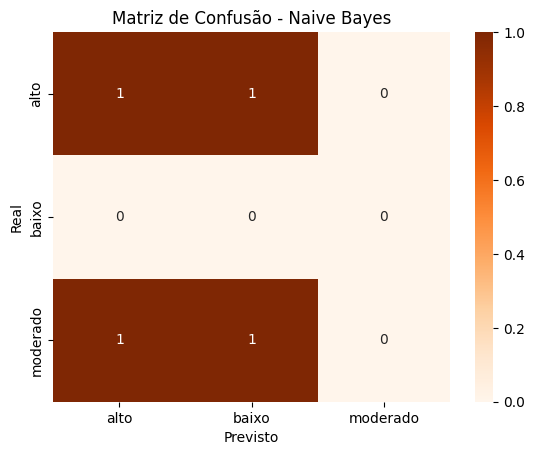


Matriz de Confusão:
[[1 1 0]
 [0 0 0]
 [1 1 0]]

Relatório de classificação:
              precision    recall  f1-score   support

        alto       0.50      0.50      0.50         2
       baixo       0.00      0.00      0.00         0
    moderado       0.00      0.00      0.00         2

    accuracy                           0.25         4
   macro avg       0.17      0.17      0.17         4
weighted avg       0.25      0.25      0.25         4



In [ ]:
# divisão treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_risco_credito, y_risco_credito, test_size=0.25, random_state=1
)

# treinar modelo
naiveb = GaussianNB()
naiveb.fit(X_treino, y_treino)

# previsões
previsoes = naiveb.predict(X_teste)

# acurácia
print(f"Taxa de acerto: {accuracy_score(y_teste, previsoes):.4f}")

# matriz de confusão
cm = confusion_matrix(y_teste, previsoes)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=label_encoder_risco.classes_,
    yticklabels=label_encoder_risco.classes_,
)

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Naive Bayes')
plt.show()

# imprimir matriz (opcional, mas bom)
print("\nMatriz de Confusão:")
print(cm)

# relatório de classificação
print("\nRelatório de classificação:")
print(classification_report(
    y_teste,
    previsoes,
    target_names=label_encoder_risco.classes_,
    zero_division=0
))

#O modelo Naive Bayes apresentou desempenho insatisfatório na classificação dos dados. A acurácia obtida foi de 0,25, indicando que apenas 25% das previsões foram corretas.

#A análise da matriz de confusão mostra que a classe "alto" teve desempenho moderado, com 50% de acerto, enquanto a classe "moderado" não teve nenhuma previsão correta. Além disso, a classe "baixo" não apareceu na base de teste, impossibilitando sua avaliação.

#As métricas de precisão, recall e f1-score para algumas classes foram iguais a zero, evidenciando que o modelo não conseguiu identificar corretamente essas categorias.

#Esse resultado é influenciado principalmente pelo pequeno tamanho da base de dados de teste, o que compromete a confiabilidade das métricas. Dessa forma, conclui-se que o modelo não apresentou bom desempenho neste cenário.